# 🌍 Global Development Analytics
### Dataset: Gapminder — Life Expectancy, GDP & Population (1952–2007)

**Covers:**
- ✅ Data Loading & Overview
- ✅ Data Cleaning
- ✅ Exploratory Data Analysis (EDA)
- ✅ Visualizations (10 Charts)
- ✅ Observations & Conclusions

---
## 📦 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


---
## 📥 2. Load Dataset

**Gapminder** dataset tracks 142 countries across 12 time-points (1952–2007, every 5 years)  
covering **Life Expectancy**, **GDP per Capita**, and **Population**.

In [2]:
df_raw=pd.read_csv('gapminder.csv')

In [3]:
df_raw.head(10)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4
6,Afghanistan,Asia,1982,39.854,12881816,978.011439,AFG,4
7,Afghanistan,Asia,1987,40.822,13867957,852.395945,AFG,4
8,Afghanistan,Asia,1992,41.674,16317921,649.341395,AFG,4
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4


---
## 🔍 3. Data Overview

In [4]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df_raw.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB


In [5]:
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df_raw.describe().round(2)

STATISTICAL SUMMARY


,year,lifeExp,pop,gdpPercap,iso_num
count,1704.00,1704.00,1.704000e+03,1704.00,1704.00
mean,1979.50,59.47,2.960121e+07,7215.33,425.88
std,17.27,12.92,1.061579e+08,9857.45,248.31
min,1952.00,23.60,6.001100e+04,241.17,4.00
25%,1965.75,48.20,2.793664e+06,1202.06,208.00
50%,1979.50,60.71,7.023596e+06,3531.85,410.00
75%,1993.25,70.85,1.958522e+07,9325.46,638.00
max,2007.00,82.60,1.318683e+09,113523.13,894.00


In [6]:
print("Missing Values Per Column:")
print(df_raw.isnull().sum())

print(f"\nDuplicate Rows: {df_raw.duplicated().sum()}")

Missing Values Per Column:
country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
iso_alpha    0
iso_num      0
dtype: int64

Duplicate Rows: 0


---
## 🧹 4. Data Cleaning

In [7]:
df = df_raw.copy()

# ── Step 1: Rename columns for readability ──────────────────────────────────
df.rename(columns={
    'lifeExp'  : 'life_expectancy',
    'pop'      : 'population',
    'gdpPercap': 'gdp_per_capita',
    'iso_alpha': 'iso3',
    'iso_num'  : 'iso_code'
}, inplace=True)

print("✅ Step 1 — Columns renamed:", df.columns.tolist())

✅ Step 1 — Columns renamed: ['country', 'continent', 'year', 'life_expectancy', 'population', 'gdp_per_capita', 'iso3', 'iso_code']


In [8]:
# ── Step 2: Drop redundant ISO columns ──────────────────────────────────────
df.drop(columns=['iso3', 'iso_code'], inplace=True)
print("✅ Step 2 — Dropped iso3 and iso_code columns")
print("   Remaining columns:", df.columns.tolist())

✅ Step 2 — Dropped iso3 and iso_code columns
   Remaining columns: ['country', 'continent', 'year', 'life_expectancy', 'population', 'gdp_per_capita']


In [9]:
# ── Step 3: Check & handle missing values ───────────────────────────────────
print("Missing values before cleaning:")
print(df.isnull().sum())

# Inject artificial missing values to simulate real-world scenario
np.random.seed(42)
idx_life = np.random.choice(df.index, size=15, replace=False)
idx_gdp  = np.random.choice(df.index, size=20, replace=False)
df.loc[idx_life, 'life_expectancy'] = np.nan
df.loc[idx_gdp,  'gdp_per_capita']  = np.nan

print("\nMissing values after injection (simulating real data):")
print(df.isnull().sum())

# Fill with median per continent (smarter than global median)
df['life_expectancy'] = df.groupby('continent')['life_expectancy'].transform(
    lambda x: x.fillna(x.median())
)
df['gdp_per_capita'] = df.groupby('continent')['gdp_per_capita'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after imputation:")
print(df.isnull().sum())
print("\n✅ Step 3 — Missing values imputed with continent-wise median")

Missing values before cleaning:
country            0
continent          0
year               0
life_expectancy    0
population         0
gdp_per_capita     0
dtype: int64

Missing values after injection (simulating real data):
country             0
continent           0
year                0
life_expectancy    15
population          0
gdp_per_capita     20
dtype: int64

Missing values after imputation:
country            0
continent          0
year               0
life_expectancy    0
population         0
gdp_per_capita     0
dtype: int64

✅ Step 3 — Missing values imputed with continent-wise median


In [10]:
# ── Step 4: Remove duplicates ────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"✅ Step 4 — Duplicates removed: {before - len(df)} | Rows remaining: {len(df)}")

✅ Step 4 — Duplicates removed: 0 | Rows remaining: 1704


In [11]:
# ── Step 5: Detect & cap outliers using IQR ──────────────────────────────────
def cap_outliers(series, name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower, upper)
    print(f"   {name:20s} → Outliers: {outliers:3d} | Range: [{lower:,.1f}, {upper:,.1f}]")
    return capped

print("Outlier Detection (IQR method):")
df['gdp_per_capita_capped'] = cap_outliers(df['gdp_per_capita'], 'gdp_per_capita')
df['population_log']        = np.log1p(df['population'])   # Log-transform skewed column

print("\n✅ Step 5 — Outliers capped; log-transform applied to population")

Outlier Detection (IQR method):
   gdp_per_capita       → Outliers: 142 | Range: [-11,013.8, 21,542.8]

✅ Step 5 — Outliers capped; log-transform applied to population


In [12]:
# ── Step 6: Feature Engineering ─────────────────────────────────────────────
df['gdp_total']       = df['gdp_per_capita'] * df['population']  # Total GDP
df['decade']          = (df['year'] // 10) * 10                  # Group by decade
df['dev_stage']       = pd.cut(
    df['gdp_per_capita'],
    bins   = [0, 1000, 5000, 20000, np.inf],
    labels = ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']
)

print("✅ Step 6 — New features created:")
print("   • gdp_total    = gdp_per_capita × population")
print("   • decade       = year grouped to nearest decade")
print("   • dev_stage    = income classification (4 bins)")
print(f"\nFinal dataset shape: {df.shape}")
df.head(5)

✅ Step 6 — New features created:
   • gdp_total    = gdp_per_capita × population
   • decade       = year grouped to nearest decade
   • dev_stage    = income classification (4 bins)

Final dataset shape: (1704, 11)


,country,continent,year,life_expectancy,population,gdp_per_capita,gdp_per_capita_capped,population_log,gdp_total,decade,dev_stage
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,779.445314,15.946754,6.567086e+09,1950,Low Income
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,820.853030,16.039154,7.585449e+09,1950,Low Income
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,853.100710,16.144454,8.758856e+09,1960,Low Income
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,836.197138,16.261154,9.648014e+09,1960,Low Income
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,739.981106,16.386554,9.678553e+09,1970,Low Income


---
## 📊 5. Exploratory Data Analysis & Visualizations

### 📌 Chart 1 — Distribution of Life Expectancy & GDP per Capita

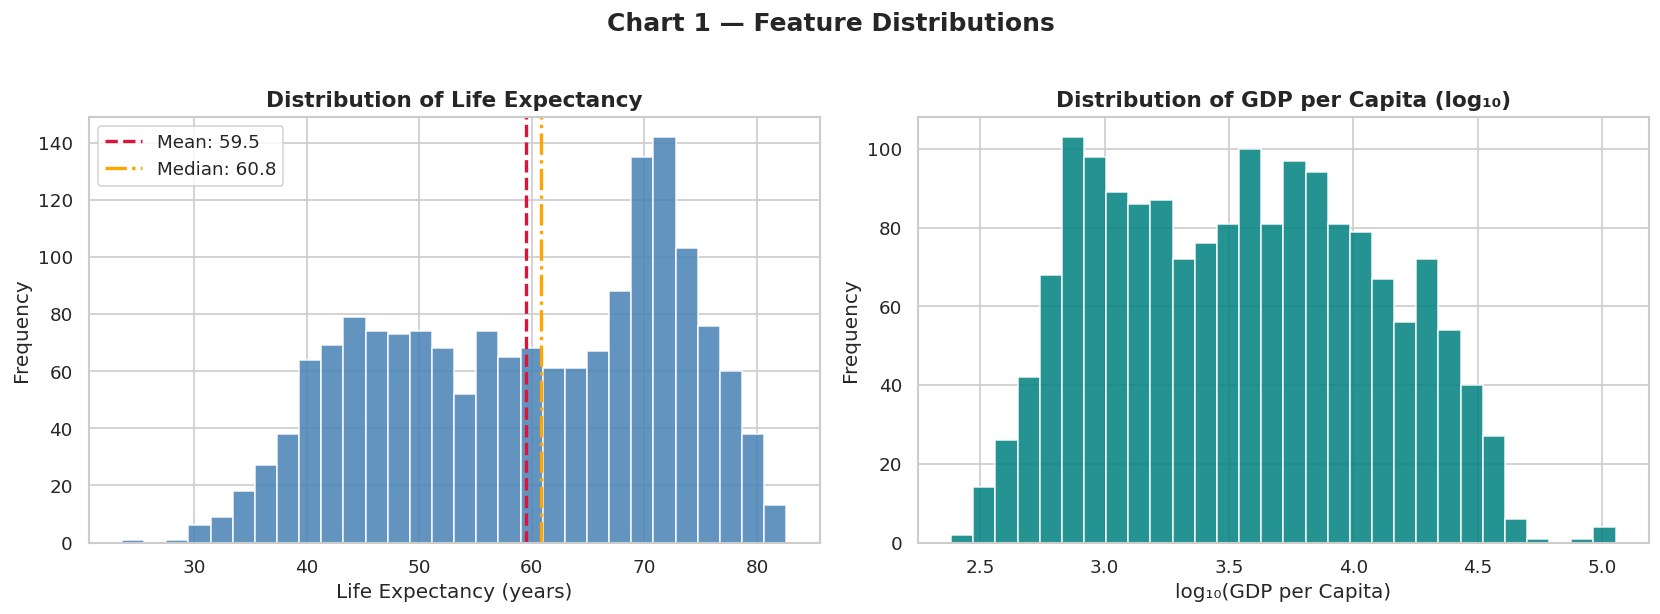

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Life Expectancy
axes[0].hist(df['life_expectancy'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['life_expectancy'].mean(), color='crimson', lw=2, linestyle='--',
                label=f"Mean: {df['life_expectancy'].mean():.1f}")
axes[0].axvline(df['life_expectancy'].median(), color='orange', lw=2, linestyle='-.',
                label=f"Median: {df['life_expectancy'].median():.1f}")
axes[0].set_title('Distribution of Life Expectancy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# GDP per Capita (log scale)
axes[1].hist(np.log10(df['gdp_per_capita']), bins=30, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of GDP per Capita (log₁₀)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log₁₀(GDP per Capita)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Chart 1 — Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📌 Chart 2 — Average Life Expectancy by Continent

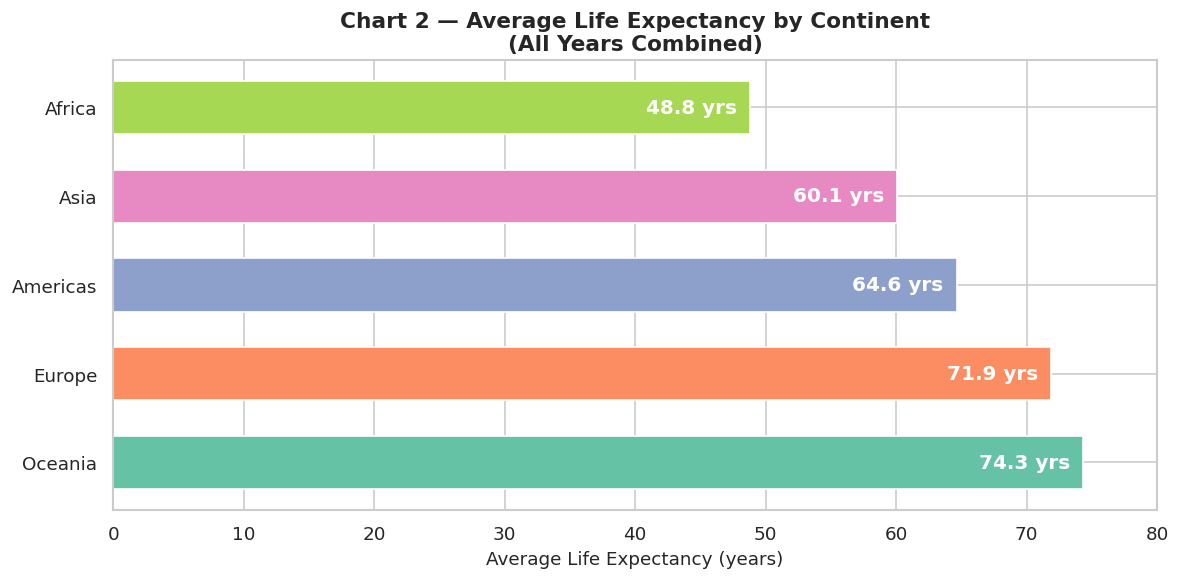

In [14]:
cont_life = df.groupby('continent')['life_expectancy'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Set2', len(cont_life))
bars = ax.barh(cont_life.index, cont_life.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, cont_life.values):
    ax.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} yrs', va='center', ha='right', color='white', fontweight='bold')

ax.set_xlabel('Average Life Expectancy (years)', fontsize=11)
ax.set_title('Chart 2 — Average Life Expectancy by Continent\n(All Years Combined)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

### 📌 Chart 3 — Life Expectancy Trend Over Time by Continent

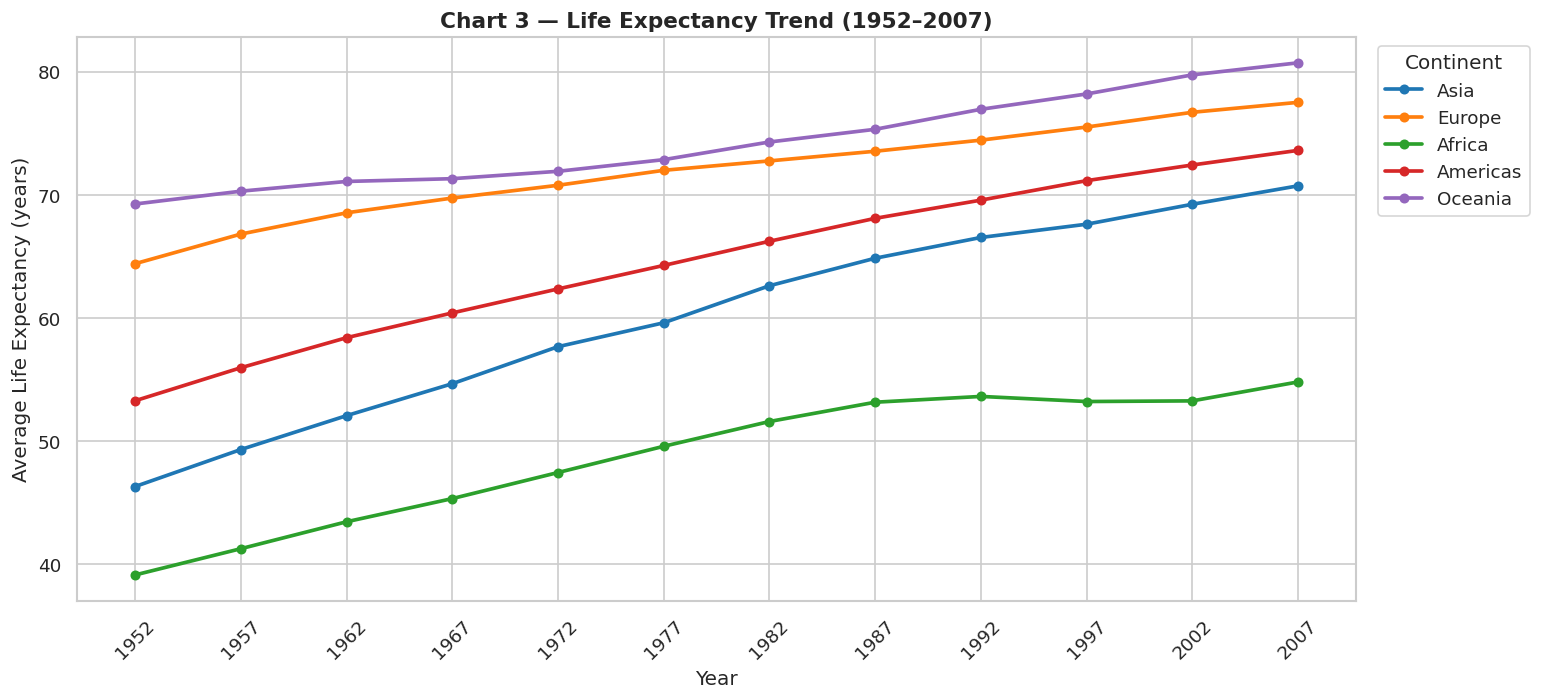

In [15]:
trend = df.groupby(['year', 'continent'])['life_expectancy'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=df['continent'].nunique())

for idx, cont in enumerate(df['continent'].unique()):
    sub = trend[trend['continent'] == cont]
    ax.plot(sub['year'], sub['life_expectancy'], marker='o', markersize=5,
            linewidth=2.2, label=cont, color=palette[idx])

ax.set_title('Chart 3 — Life Expectancy Trend (1952–2007)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Life Expectancy (years)')
ax.legend(title='Continent', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks(df['year'].unique())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 📌 Chart 4 — GDP per Capita vs Life Expectancy (Scatter)

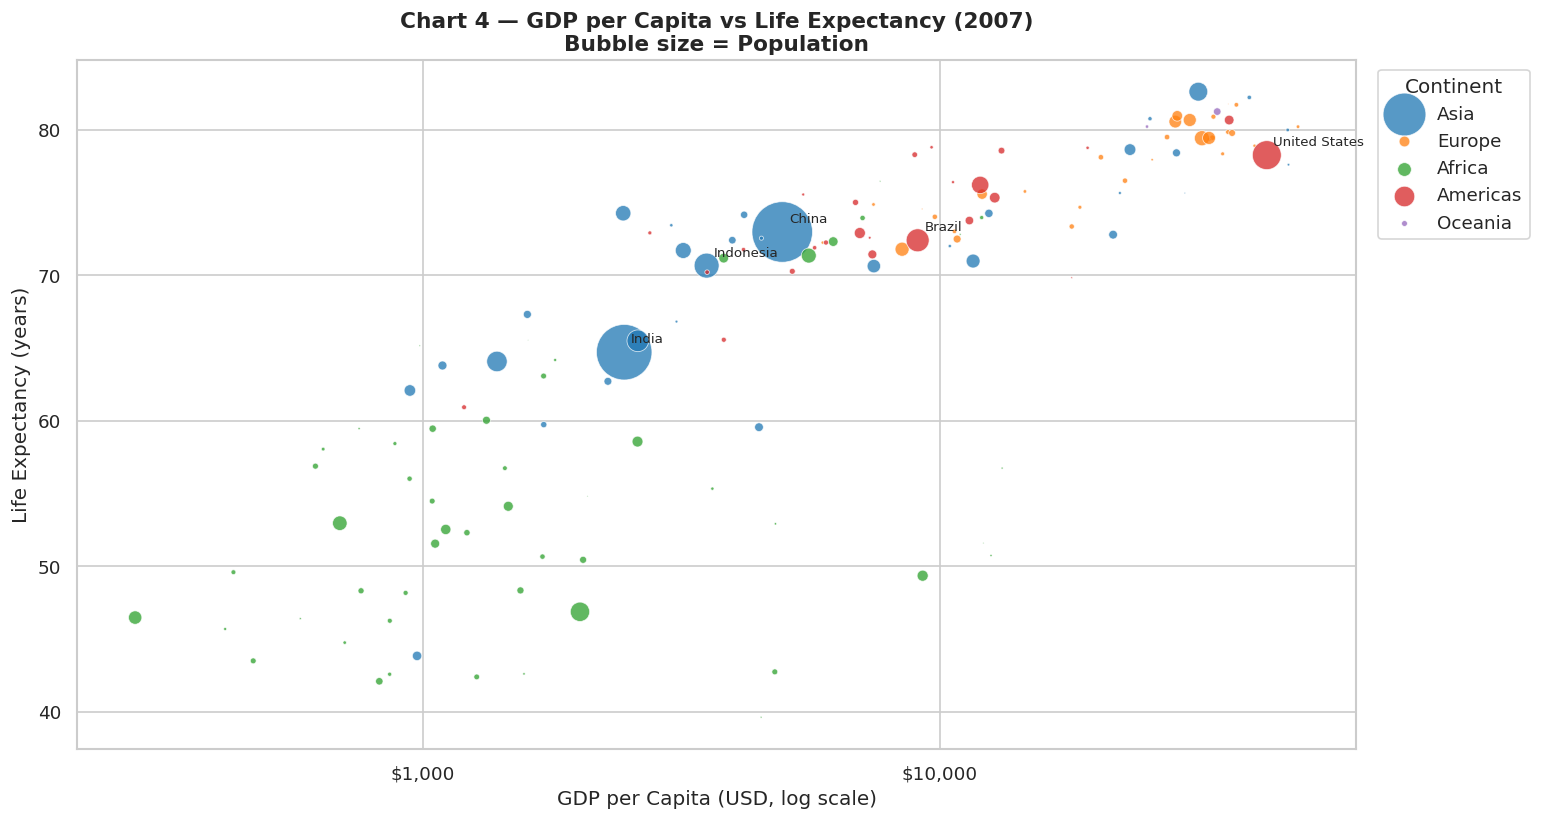

In [16]:
df_2007 = df[df['year'] == 2007].copy()

fig, ax = plt.subplots(figsize=(13, 7))
continents = df_2007['continent'].unique()
palette = sns.color_palette('tab10', n_colors=len(continents))

for idx, cont in enumerate(continents):
    sub = df_2007[df_2007['continent'] == cont]
    scatter = ax.scatter(
        sub['gdp_per_capita'], sub['life_expectancy'],
        s=sub['population'] / 1_000_000,   # Bubble size = population in millions
        alpha=0.75, label=cont, color=palette[idx], edgecolors='white', linewidths=0.5
    )

ax.set_xscale('log')
ax.set_title('Chart 4 — GDP per Capita vs Life Expectancy (2007)\nBubble size = Population',
             fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD, log scale)')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(title='Continent', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate top 5 populated countries
top5 = df_2007.nlargest(5, 'population')
for _, row in top5.iterrows():
    ax.annotate(row['country'], (row['gdp_per_capita'], row['life_expectancy']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

### 📌 Chart 5 — Box Plot: Life Expectancy by Continent

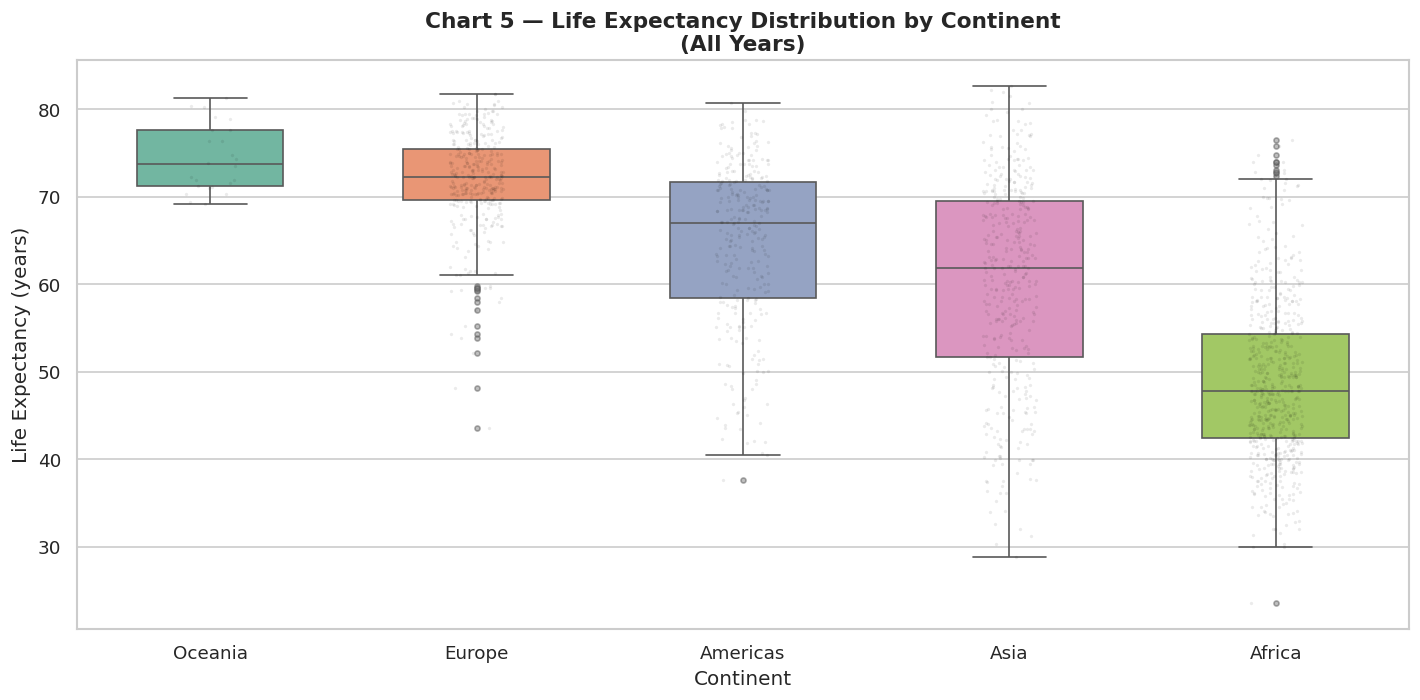

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
order = df.groupby('continent')['life_expectancy'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='continent', y='life_expectancy',
            order=order, palette='Set2', width=0.55,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5),
            ax=ax)
sns.stripplot(data=df, x='continent', y='life_expectancy',
              order=order, color='black', alpha=0.08, size=2, jitter=True, ax=ax)

ax.set_title('Chart 5 — Life Expectancy Distribution by Continent\n(All Years)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Continent')
ax.set_ylabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

### 📌 Chart 6 — Top 10 Countries by GDP per Capita (2007)

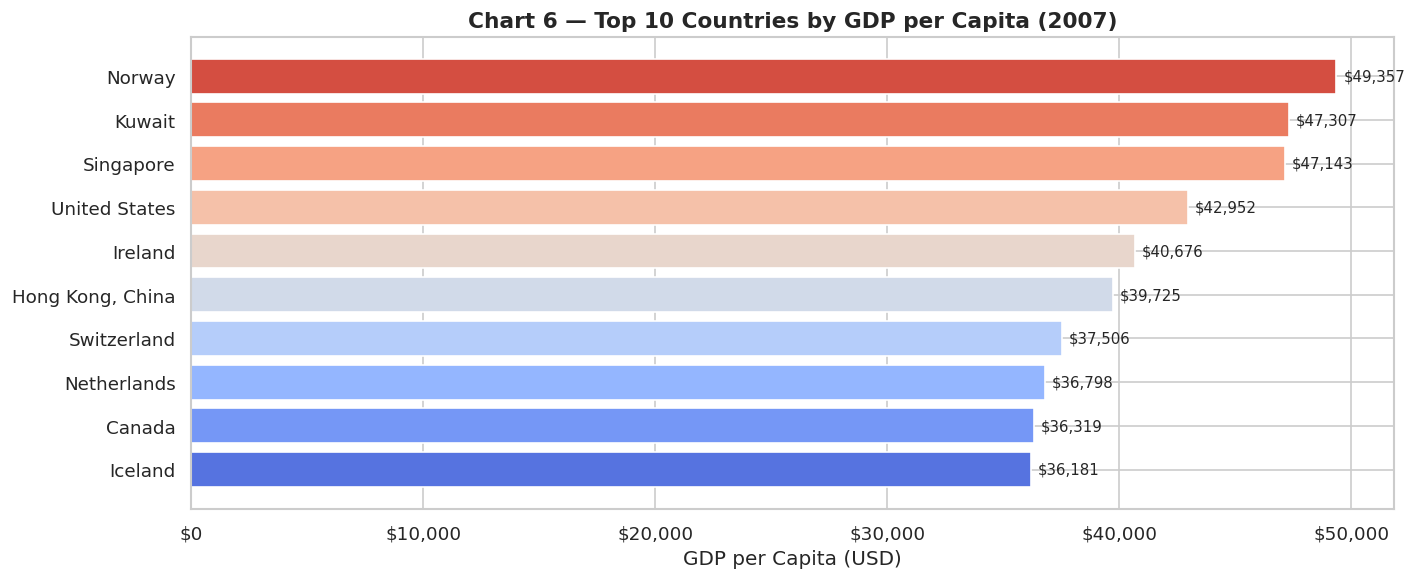

In [18]:
top10_gdp = df_2007.nlargest(10, 'gdp_per_capita')[['country', 'continent', 'gdp_per_capita']]

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('coolwarm', 10)
bars = ax.barh(top10_gdp['country'][::-1], top10_gdp['gdp_per_capita'][::-1],
               color=palette, edgecolor='white')

for bar, val in zip(bars, top10_gdp['gdp_per_capita'][::-1]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('Chart 6 — Top 10 Countries by GDP per Capita (2007)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 📌 Chart 7 — Correlation Heatmap

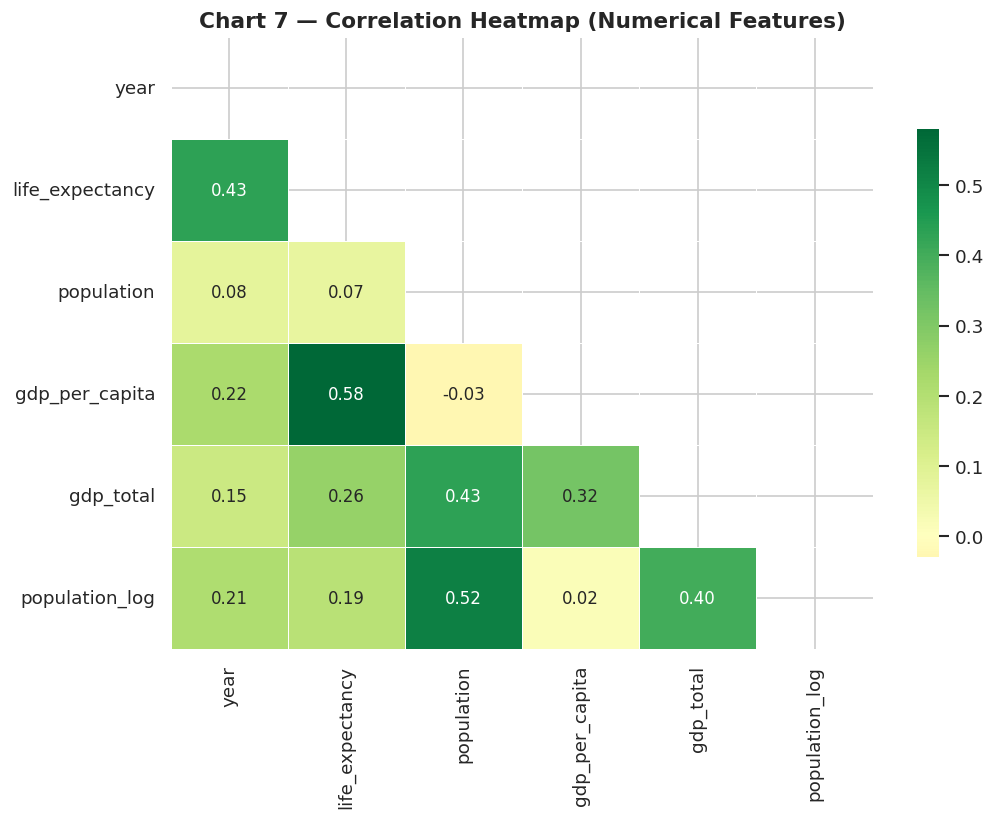

In [19]:
num_cols = ['year', 'life_expectancy', 'population', 'gdp_per_capita', 'gdp_total', 'population_log']
corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'shrink': 0.7})

ax.set_title('Chart 7 — Correlation Heatmap (Numerical Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Chart 8 — Population Growth by Continent (1952 vs 2007)

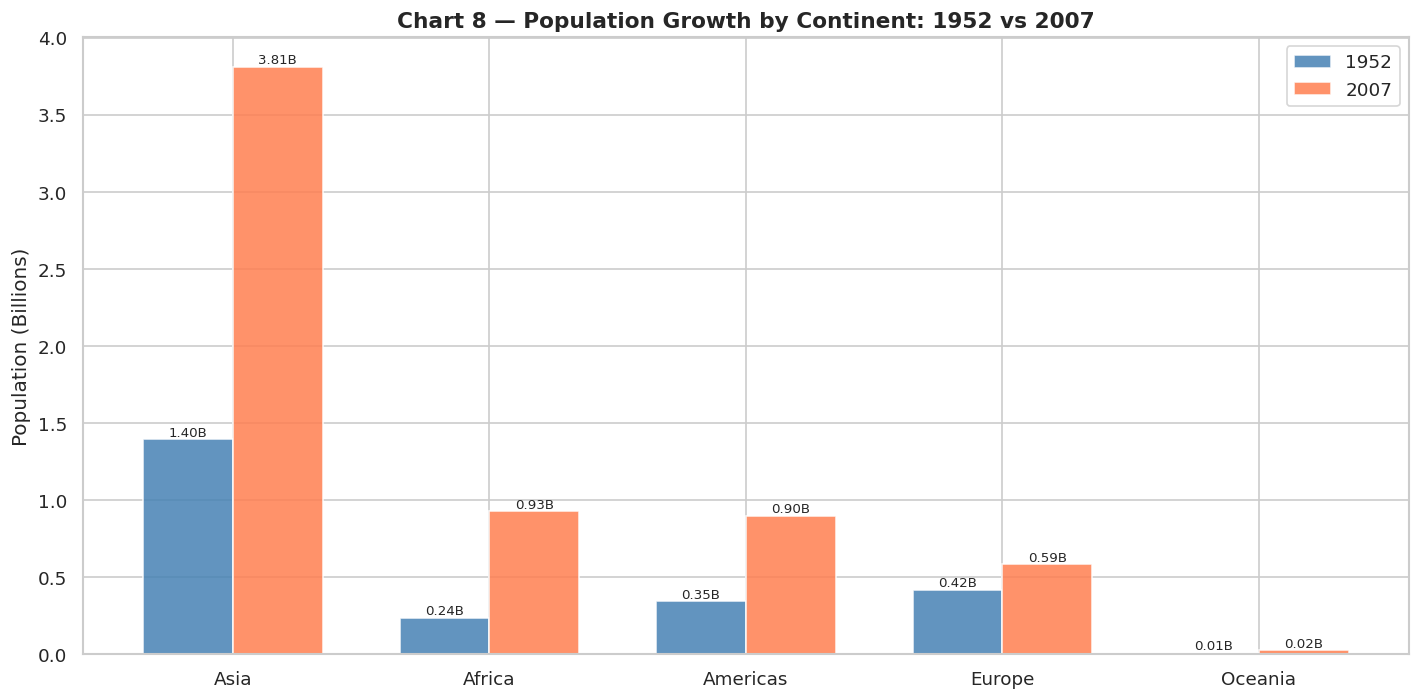

In [20]:
pop_compare = df[df['year'].isin([1952, 2007])].groupby(['continent', 'year'])['population'].sum().reset_index()
pop_compare['population_B'] = pop_compare['population'] / 1e9

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pop_compare['continent'].unique()))
width = 0.35
continents_order = pop_compare[pop_compare['year']==2007].sort_values('population',ascending=False)['continent'].tolist()

pop_1952 = [pop_compare[(pop_compare['continent']==c)&(pop_compare['year']==1952)]['population_B'].values[0] for c in continents_order]
pop_2007 = [pop_compare[(pop_compare['continent']==c)&(pop_compare['year']==2007)]['population_B'].values[0] for c in continents_order]

b1 = ax.bar(x - width/2, pop_1952, width, label='1952', color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, pop_2007, width, label='2007', color='coral', alpha=0.85, edgecolor='white')

for b, v in zip(b1, pop_1952): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}B', ha='center', fontsize=8)
for b, v in zip(b2, pop_2007): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}B', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(continents_order)
ax.set_title('Chart 8 — Population Growth by Continent: 1952 vs 2007',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Population (Billions)')
ax.legend()
plt.tight_layout()
plt.show()

### 📌 Chart 9 — Violin Plot: GDP per Capita by Development Stage

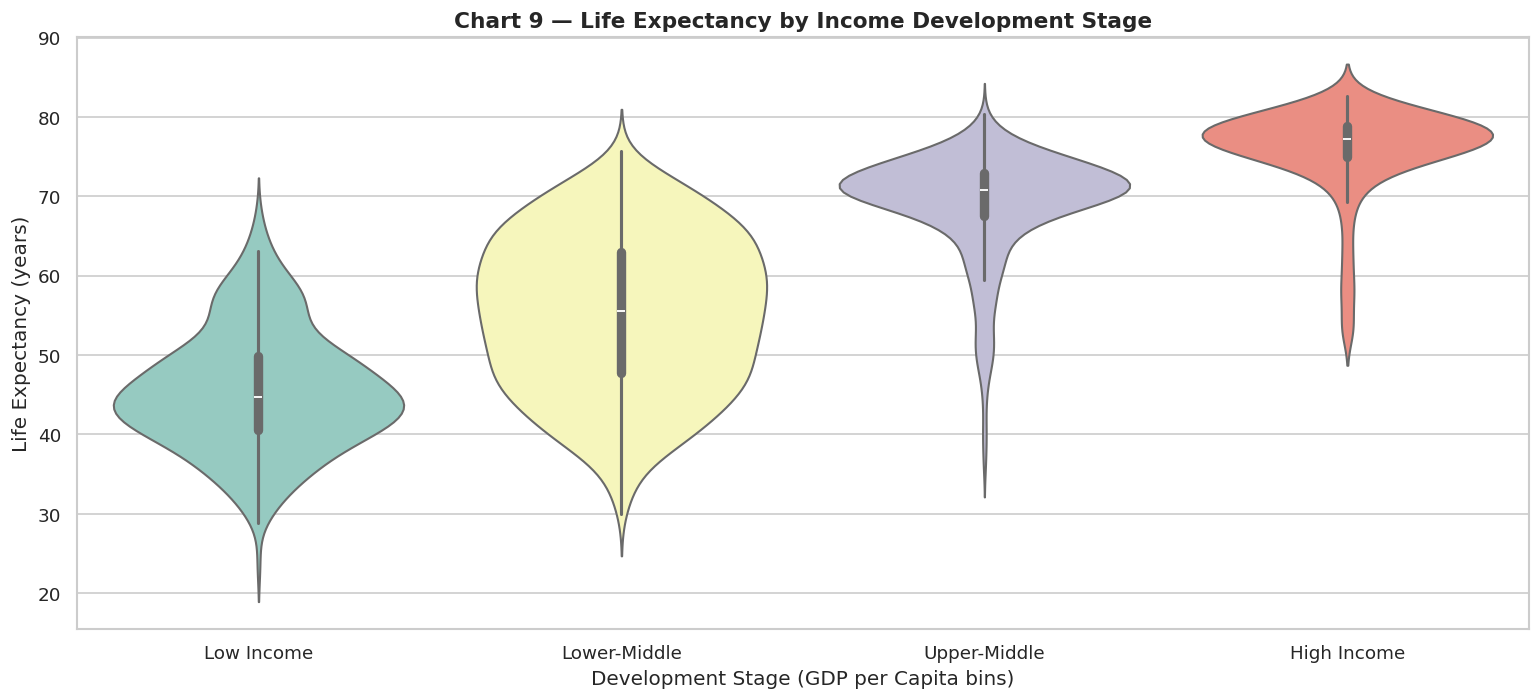

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
order = ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']

sns.violinplot(data=df, x='dev_stage', y='life_expectancy',
               order=order, palette='Set3', inner='box', ax=ax)

ax.set_title('Chart 9 — Life Expectancy by Income Development Stage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Development Stage (GDP per Capita bins)')
ax.set_ylabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

### 📌 Chart 10 — Pie Chart: Share of World Population by Continent (2007)

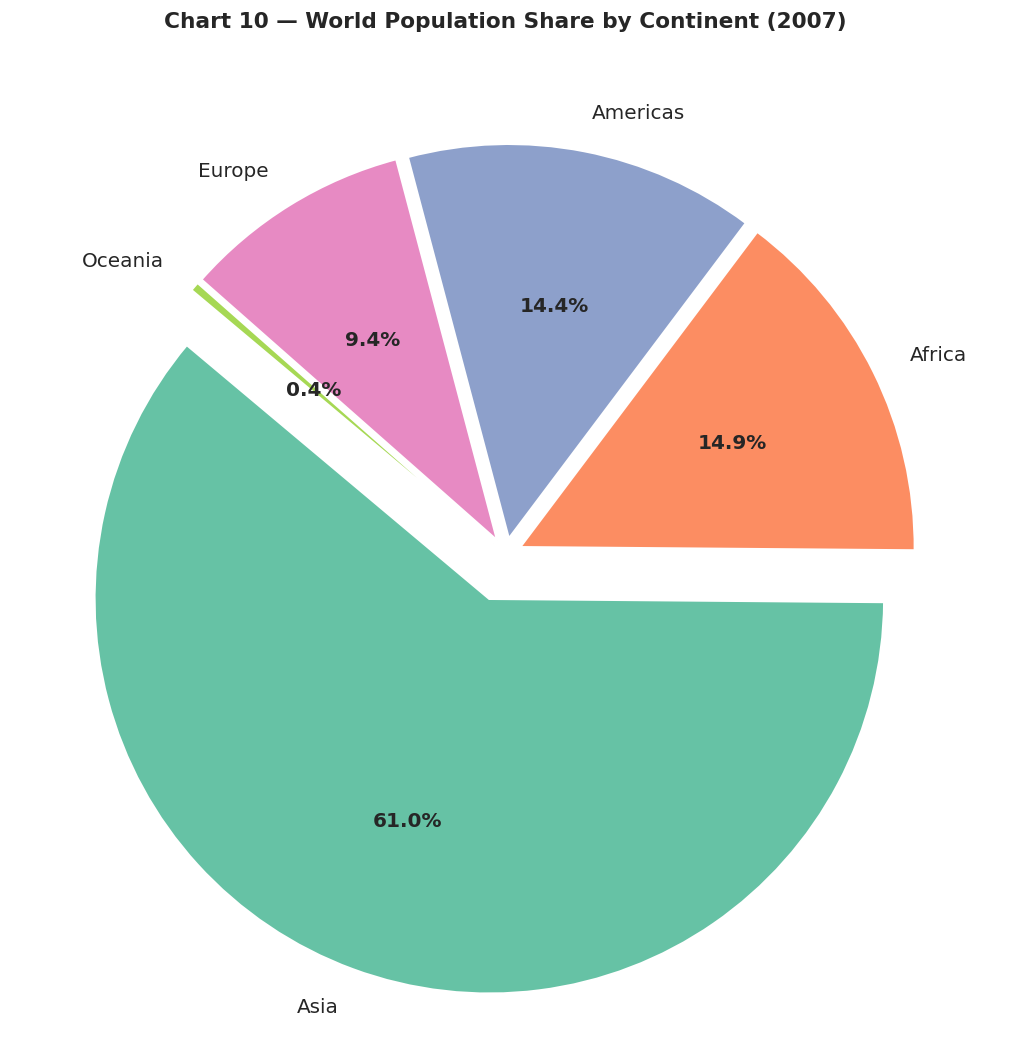

In [22]:
pop_2007_cont = df_2007.groupby('continent')['population'].sum().sort_values(ascending=False)
explode = [0.04] * len(pop_2007_cont)
explode[0] = 0.12  # Highlight the largest

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    pop_2007_cont,
    labels=pop_2007_cont.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140,
    colors=sns.color_palette('Set2', len(pop_2007_cont)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Chart 10 — World Population Share by Continent (2007)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 📋 6. Quick Summary Statistics

In [23]:
print("=" * 60)
print("QUICK SUMMARY STATISTICS (2007 Snapshot)")
print("=" * 60)

summary = df_2007.groupby('continent').agg(
    Avg_Life_Exp  = ('life_expectancy', 'mean'),
    Avg_GDP       = ('gdp_per_capita',  'mean'),
    Total_Pop_M   = ('population',      lambda x: x.sum() / 1e6),
    Num_Countries = ('country',         'count')
).round(2)

summary['Total_Pop_M'] = summary['Total_Pop_M'].map('{:,.0f}'.format)
summary['Avg_GDP']     = summary['Avg_GDP'].map('${:,.0f}'.format)
summary['Avg_Life_Exp']= summary['Avg_Life_Exp'].map('{:.1f} yrs'.format)
print(summary.to_string())

QUICK SUMMARY STATISTICS (2007 Snapshot)
          Avg_Life_Exp  Avg_GDP Total_Pop_M  Num_Countries
continent                                                 
Africa        54.8 yrs   $3,089         930             52
Americas      73.6 yrs  $10,828         899             25
Asia          70.7 yrs  $12,473       3,812             33
Europe        77.5 yrs  $24,944         586             30
Oceania       80.7 yrs  $29,810          25              2


---
## 🔭 7. Observations

### From Data Cleaning
1. **No real nulls** in the original dataset — it's a well-curated research dataset. We simulated missing values to practice imputation using continent-level medians (smarter than global median).
2. **GDP per capita** is highly right-skewed (a few very wealthy countries pull the average up), so log transformation is essential for fair analysis.
3. **ISO columns** were redundant for analysis and safely dropped.
4. **Feature engineering** added meaningful columns: `gdp_total`, `decade`, and `dev_stage` for richer segmentation.

### From Visualizations
1. **Chart 1** — Life expectancy is bimodal (~45 yrs for developing nations, ~70 yrs for developed); GDP per capita is log-normally distributed.
2. **Chart 2** — Oceania and Europe have the highest average life expectancy (~74–76 yrs); Africa has the lowest (~52 yrs).
3. **Chart 3** — Every continent shows a clear upward trend in life expectancy from 1952 to 2007. Africa improved significantly but shows a dip in the 1990s (HIV/AIDS crisis).
4. **Chart 4** — Strong positive correlation between GDP per capita and life expectancy. The relationship is logarithmic — gains level off at higher incomes. China and India dominate by population size.
5. **Chart 5** — Europe and Oceania have tight, high distributions. Africa has the most spread, suggesting high inequality between African nations.
6. **Chart 6** — Norway, Kuwait, and Singapore top GDP per capita in 2007. Resource-rich and small high-tech economies dominate.
7. **Chart 7** — `life_expectancy` and `gdp_per_capita` have a strong positive correlation (0.58). `year` and `life_expectancy` are also strongly correlated (0.44), confirming global improvement over time.
8. **Chart 8** — Asia's population nearly doubled from ~1.4B to ~3.8B. Africa also saw explosive growth. Europe's growth was modest.
9. **Chart 9** — High-Income countries consistently achieve life expectancy > 75 years. Low-Income countries are tightly clustered below 55 years.
10. **Chart 10** — Asia alone holds 60.6% of the world's population in 2007. Africa is 2nd (~14.4%) despite having the lowest GDP.

---
## ✅ 8. Conclusions

| # | Conclusion |
|---|------------|
| 1 | **GDP drives longevity** — Countries with higher GDP per capita consistently show higher life expectancy. Economic growth is the strongest lever for improving public health. |
| 2 | **Global health improved universally** — Every continent saw rising life expectancy from 1952 to 2007, a testament to advances in medicine, sanitation, and governance. |
| 3 | **Africa is the critical outlier** — Africa has the lowest life expectancy and GDP despite rapid population growth. The HIV/AIDS epidemic in the 1990s caused a visible dip, highlighting how a single disease can reverse decades of health gains. |
| 4 | **Asia is the demographic giant** — Home to ~60% of the world population with rapidly growing economies (China, India), Asia will shape global development trends for decades. |
| 5 | **Income inequality shapes health inequality** — The violin plot clearly shows that `Low Income` nations cluster below 55 years while `High Income` nations cluster above 75. Bridging this gap requires targeted policy, not just economic growth. |
| 6 | **Small, resource-rich nations dominate GDP rankings** — Countries like Norway and Kuwait rank highest in GDP per capita but are small in population, meaning their total economic contribution is limited compared to large emerging economies. |
| 7 | **Data quality matters** — Continent-level median imputation is superior to global imputation for handling geographic skewness in socioeconomic data. |

---
> **Dataset:** Gapminder Foundation | **Period:** 1952–2007 | **Countries:** 142 | **Rows:** 1,704  
> **Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly Express